In [1]:
import os
import wandb
import pandas as pd
import numpy as np

# 1. Setup API
api = wandb.Api()
entity = "luis-perdigao-instituto-superior-t-cnico"
project = "PCS_ET_v22"
sweep_ids = ["0jf00dgr", "8m4loipf"] 

data_list = []

for sweep_id in sweep_ids:
    print(f"Fetching runs from sweep: {sweep_id}...")
    try:
        sweep = api.sweep(f"{entity}/{project}/{sweep_id}")
        runs = sweep.runs
        print(f"  Found {len(runs)} runs. Processing history...")
    except Exception as e:
        print(f"  Error accessing sweep {sweep_id}: {e}")
        continue 

    for run in runs:
        # A. Get Config
        config = {k: v for k, v in run.config.items() if not k.startswith('_')}
        
        # B. Fetch History for BOTH ranking and classification
        keys_to_fetch = ["accuracy_validation", "c_accuracy_validation"]
        history = pd.DataFrame(run.scan_history(keys=keys_to_fetch))
        
        best_val_rank = None
        best_val_class = None
        
        if not history.empty and "accuracy_validation" in history.columns:
            # Find the row index where ranking accuracy is at its absolute highest
            best_idx = history["accuracy_validation"].idxmax()
            
            # Extract ranking accuracy at that peak
            best_val_rank = history.loc[best_idx, "accuracy_validation"]
            
            # Extract classification accuracy at that SAME peak (if it exists)
            if "c_accuracy_validation" in history.columns:
                best_val_class = history.loc[best_idx, "c_accuracy_validation"]
        else:
            # Fallback to summary if history is missing
            best_val_rank = run.summary.get("max_accuracy_validation", run.summary.get("accuracy_validation", None))
            best_val_class = run.summary.get("c_accuracy_validation", None)

        # C. Handle potential naming differences
        margin = config.get("ranking_margin", config.get("rank_margin", None))
        seed = config.get("seed", pd.NA) 

        # D. Build Row (Now including classification accuracy)
        if margin is not None and best_val_rank is not None:
            data_list.append({
                "sweep_id": sweep_id,
                "run_name": run.name,
                "backbone": config.get("backbone", "unknown"),
                "margin": margin,
                "seed": seed, 
                "val_rank_acc": best_val_rank,
                "val_class_acc": best_val_class # Added this new column!
            })

# 3. Save to CSV in results folder
os.makedirs("results", exist_ok=True)
filename = "results/margin_sweep_results.csv"
df = pd.DataFrame(data_list)
df.to_csv(filename, index=False)
print(f"Done! Saved {len(df)} total runs to '{filename}'.")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luis-perdigao (luis-perdigao-instituto-superior-t-cnico) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetching runs from sweep: 0jf00dgr...
  Found 165 runs. Processing history...
Fetching runs from sweep: 8m4loipf...
  Found 90 runs. Processing history...
Done! Saved 255 total runs to 'results/margin_sweep_results.csv'.


/tmp/ipykernel_3890686/1570576345.py:81: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3890686/1570576345.py:86: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(image_path, dpi=300, bbox_inches='tight')
/home/csantiago/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


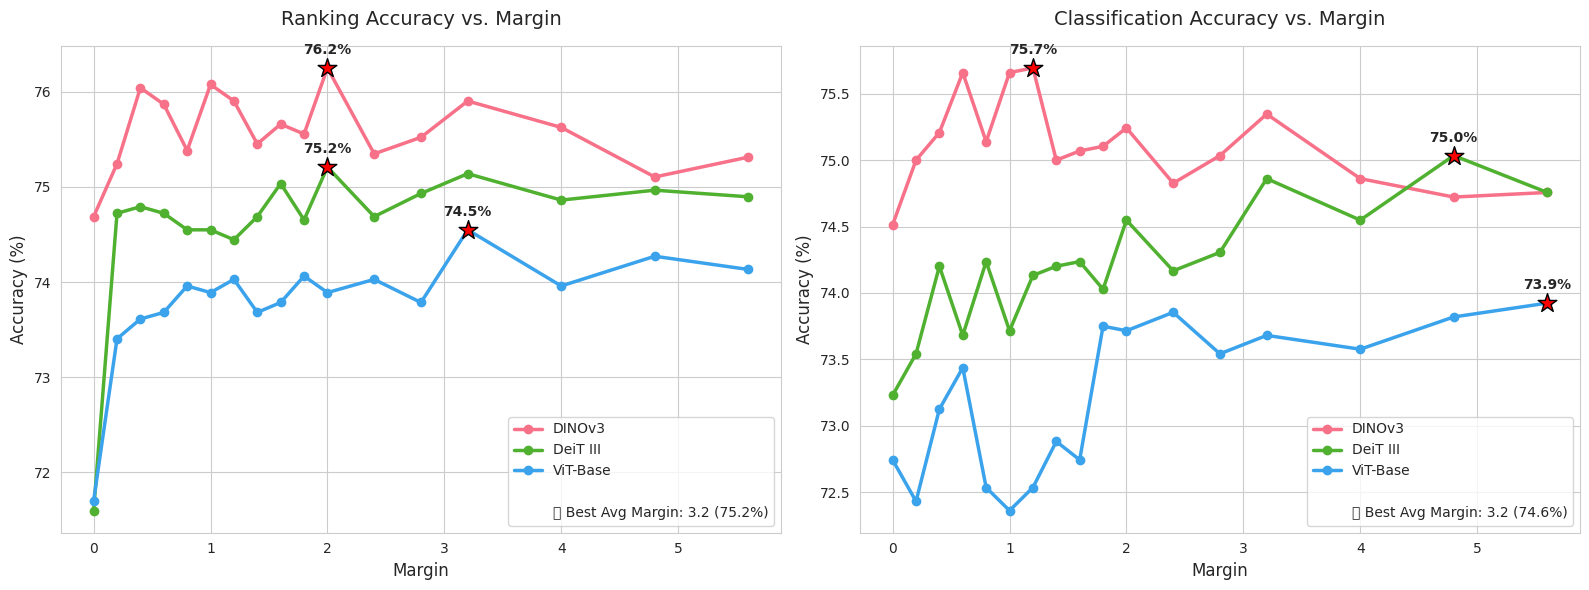

Plot saved successfully as 'images/margin_plots_combined.png'!


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Load Data from results folder
df = pd.read_csv("results/margin_sweep_results.csv")

# Clean backbone names for display
backbone_map = {
    'dinov3_vitb16': 'DINOv3',
    'vit_base_patch16_224': 'ViT-Base', 
    'deit3_base_patch16_224': 'DeiT III',
    'vit_base_patch16_clip_224': 'CLIP',
    'clip': 'CLIP',
    'vit_small': 'ViT-Small'
}
df['backbone'] = df['backbone'].map(backbone_map).fillna(df['backbone'])

# Aggregate BOTH accuracies (averaging the seeds across both sweeps)
df_agg = df.groupby(['backbone', 'margin'], as_index=False)[['val_rank_acc', 'val_class_acc']].mean()

# 2. Find the Margins with the Best Average Across ALL Backbones
# For Ranking
avg_per_margin_rank = df_agg.groupby('margin')['val_rank_acc'].mean()
best_avg_margin_rank = avg_per_margin_rank.idxmax()
best_avg_val_rank = avg_per_margin_rank.max()

# For Classification
avg_per_margin_class = df_agg.groupby('margin')['val_class_acc'].mean()
best_avg_margin_class = avg_per_margin_class.idxmax()
best_avg_val_class = avg_per_margin_class.max()

# 3. Plotting Setup (1 row, 2 columns for side-by-side plots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

backbones = df_agg['backbone'].unique()
colors = sns.color_palette("husl", len(backbones))

# Helper function to plot a specific metric on a specific axis
def plot_metric(ax, metric_col, title, best_avg_margin, best_avg_val):
    for i, backbone in enumerate(backbones):
        subset = df_agg[df_agg['backbone'] == backbone].sort_values('margin')
        
        # Line plot
        ax.plot(subset['margin'], subset[metric_col] * 100, marker='o', 
                label=f"{backbone}", color=colors[i], linewidth=2.5, markersize=6)
        
        # Highlight highest accuracy for this backbone
        best_idx = subset[metric_col].idxmax()
        best_row = subset.loc[best_idx]
        
        ax.scatter(best_row['margin'], best_row[metric_col] * 100, 
                   color='red', s=200, zorder=5, edgecolor='black', marker='*')
        
        # Text annotation near the star
        ax.annotate(f"{best_row[metric_col]*100:.1f}%", 
                    (best_row['margin'], best_row[metric_col] * 100),
                    textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, weight='bold')

    # Aesthetics
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Margin", fontsize=12)
    ax.set_ylabel("Accuracy (%)", fontsize=12)

    # Custom Legend
    handles, labels = ax.get_legend_handles_labels()
    blank_patch = mpatches.Patch(color='none', label=' ')
    best_avg_patch = mpatches.Patch(color='none', label=f'🏆 Best Avg Margin: {best_avg_margin} ({best_avg_val*100:.1f}%)')
    handles.extend([blank_patch, best_avg_patch])
    labels.extend([blank_patch.get_label(), best_avg_patch.get_label()])
    
    ax.legend(handles=handles, labels=labels, loc="lower right", fontsize=10)

# 4. Generate the two plots
plot_metric(axes[0], 'val_rank_acc', "Ranking Accuracy vs. Margin", best_avg_margin_rank, best_avg_val_rank)
plot_metric(axes[1], 'val_class_acc', "Classification Accuracy vs. Margin", best_avg_margin_class, best_avg_val_class)

plt.tight_layout()

# 5. SAVE THE PLOT AS A HIGH-RESOLUTION PICTURE IN IMAGES FOLDER
os.makedirs("images", exist_ok=True)
image_path = "images/margin_plots_combined.png"
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()
print(f"Plot saved successfully as '{image_path}'!")